# Does NER Filtering Improve Topic Modeling?
## Entity-Centric BERTopic
**Juan J. Arango and Taha Yigit Ölmez** (University of Trier)

Comparing BERTopic performance across raw text and two entity filtered conditions (spaCy `en_core_web_trf` vs. `dslim/distilbert-NER`) on the BBC News dataset.

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch

from datasets import load_dataset
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from transformers import pipeline

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import silhouette_score
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

device = 0 if torch.cuda.is_available() else -1

/home/juanj/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset
We load BBC News directly from Hugging Face (`gopalkalpande/bbc-news-summary`), keeping original casing intact for NER.

In [2]:
dataset = load_dataset("gopalkalpande/bbc-news-summary", split="train")
raw_corpus = list(dataset["Articles"])
print(f"Loaded {len(raw_corpus)} articles from Hugging Face.")
raw_corpus[0][:160] + "..."


Loaded 2224 articles from Hugging Face.


"Budget to set scene for election..Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth B..."

## Entity Extraction & 1:1:1 Alignment
Extracting named entities with spaCy (`en_core_web_trf`) and DistilBERT-NER (`dslim/distilbert-NER`). We keep only documents where both extractors detect at least one entity, ensuring an aligned 1:1:1 comparison.

In [3]:
nlp = spacy.load("en_core_web_trf", disable=["parser"])
ner = pipeline("ner", model="dslim/distilbert-NER", aggregation_strategy="simple", device=device)

def get_spacy_entities(text):
    doc = nlp(text)
    return [
        tok.text.lower() for ent in doc.ents if ent.label_ in {"PERSON", "ORG", "GPE", "LOC"}
        for tok in ent if tok.text.lower() not in STOP_WORDS and tok.is_alpha and len(tok) > 1
    ]

def get_distilbert_entities(text):
    chunks = [p.strip() for p in text.split("\n") if p.strip()] or [text]
    with torch.inference_mode():
        res = ner(chunks)
    if isinstance(res, dict) or (res and isinstance(res[0], dict)):
        res = [res]
    tokens = []
    for chunk in res:
        for ent in chunk:
            if ent["entity_group"] in {"PER", "ORG", "LOC"}:
                for w in ent["word"].lower().split():
                    if w not in STOP_WORDS and w.isalpha() and len(w) > 1:
                        tokens.append(w)
    return tokens

cache_file = "data/corpus_extracted_cache.json"
if os.path.exists(cache_file):
    import json
    with open(cache_file) as f:
        data = json.load(f)
    paired_raw, paired_cond_a, paired_cond_b = data["paired_raw"], data["paired_cond_a"], data["paired_cond_b"]
else:
    paired_raw, paired_cond_a, paired_cond_b = [], [], []
    for text in tqdm(raw_corpus, desc="Extracting entities"):
        ea = get_spacy_entities(text)
        eb = get_distilbert_entities(text)
        if ea and eb:
            paired_raw.append(text)
            paired_cond_a.append(" ".join(ea))
            paired_cond_b.append(" ".join(eb))

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

print(f"Aligned corpus: {len(paired_raw)} documents.")

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 4836.52it/s]


Aligned corpus: 2223 documents.


## Fitting BERTopic
Holding all downstream parameters fixed across conditions: MiniLM embeddings, 2D UMAP, HDBSCAN (min size 10), and English stopword removal at c-TF-IDF.

In [4]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

def make_bertopic(seed=42):
    return BERTopic(
        embedding_model=embedding_model,
        umap_model=UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric="cosine", random_state=seed),
        hdbscan_model=HDBSCAN(min_cluster_size=10, metric="euclidean", cluster_selection_method="eom", prediction_data=True),
        vectorizer_model=CountVectorizer(stop_words="english"),
        min_topic_size=10,
        verbose=False
    )

baseline_model = make_bertopic()
cond_a_model = make_bertopic()
cond_b_model = make_bertopic()

# Load reproducible poster cluster coordinates & topics if available
umap_cache_file = "data/umap_cache.npz"
if os.path.exists(umap_cache_file):
    umap_cache = np.load(umap_cache_file)
    baseline_umap = umap_cache["baseline_umap"]
    baseline_topics = umap_cache["baseline_topics"]
    cond_a_umap = umap_cache["cond_a_umap"]
    cond_a_topics = umap_cache["cond_a_topics"]
    cond_b_umap = umap_cache["cond_b_umap"]
    cond_b_topics = umap_cache["cond_b_topics"]

    baseline_model.topics_ = baseline_topics
    cond_a_model.topics_ = cond_a_topics
    cond_b_model.topics_ = cond_b_topics
else:
    baseline_topics, _ = baseline_model.fit_transform(paired_raw)
    baseline_umap = baseline_model.umap_model.embedding_
    cond_a_topics, _ = cond_a_model.fit_transform(paired_cond_a)
    cond_a_umap = cond_a_model.umap_model.embedding_
    cond_b_topics, _ = cond_b_model.fit_transform(paired_cond_b)
    cond_b_umap = cond_b_model.umap_model.embedding_

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4332.05it/s]


## Topic Inspection

In [5]:
def show_topics(model, name, n=5):
    print(f"--- {name} ---")
    info = model.get_topic_info()
    for _, row in info[info.Topic != -1].head(n).iterrows():
        t = int(row.Topic)
        words = [w for w, _ in model.get_topic(t)[:6]]
        print(f"Topic {t:02d} (n={int(row.Count):3d}): {', '.join(words)}")
    print()

show_topics(baseline_model, "Baseline (Raw)")
show_topics(cond_a_model, "Condition A (spaCy)")
show_topics(cond_b_model, "Condition B (DistilBERT)")

--- Baseline (Raw) ---
Topic 00 (n=187): club, chelsea, united, arsenal, liverpool, league
Topic 01 (n=170): film, best, actor, films, director, awards
Topic 02 (n=149): england, wales, ireland, rugby, nations, france
Topic 03 (n=122): band, music, album, song, best, singer
Topic 04 (n=121): broadband, digital, technology, people, bt, tv

--- Condition A (spaCy) ---
Topic 00 (n=196): hollywood, foxx, scorsese, swank, drake, eastwood
Topic 01 (n=109): elvis, stone, robbie, cent, joss, presley
Topic 02 (n= 70): chelsea, arsenal, mourinho, wenger, ferguson, barcelona
Topic 03 (n= 66): eu, lse, boerse, deutsche, euronext, european
Topic 04 (n= 58): howard, labour, michael, blair, britain, tony

--- Condition B (DistilBERT) ---
Topic 00 (n=175): chelsea, liverpool, arsenal, united, real, manchester
Topic 01 (n= 98): elvis, stone, presley, keys, franz, jam
Topic 02 (n= 68): brown, labour, blair, gordon, mr, tony
Topic 03 (n= 66): drake, vera, ray, eastwood, leigh, foxx
Topic 04 (n= 51): hewi

## Evaluation Metrics
Computing $C_V$, NPMI, Topic Diversity, Outliers %, and 2D Silhouette score.

In [6]:
tokenized_corpus = [doc.lower().split() for doc in paired_raw]
dictionary = Dictionary(tokenized_corpus)

def evaluate(model, topics, umap_coords):
    topic_words, all_words = [], []
    for t_id in model.get_topics():
        if t_id == -1:
            continue
        words = [w for w, _ in model.get_topic(t_id)[:10]]
        if words:
            topic_words.append(words)
            all_words.extend(words)

    cm_cv = CoherenceModel(topics=topic_words, texts=tokenized_corpus, dictionary=dictionary, coherence="c_v")
    cm_npmi = CoherenceModel(topics=topic_words, texts=tokenized_corpus, dictionary=dictionary, coherence="c_npmi")

    topics_arr = np.array(topics)
    mask = topics_arr != -1
    sil = float(silhouette_score(umap_coords[mask], topics_arr[mask])) if len(set(topics_arr[mask])) > 1 else 0.0

    return {
        "Topics": len(model.get_topics()) - 1,
        "Outliers (%)": round((list(topics).count(-1) / len(topics)) * 100, 1),
        "C_V Coherence": round(cm_cv.get_coherence(), 3),
        "NPMI": round(cm_npmi.get_coherence(), 3),
        "Topic Diversity": round(len(set(all_words)) / len(all_words), 3) if all_words else 0.0,
        "Silhouette": round(sil, 3),
    }

results = {
    "Baseline (Raw Text)": evaluate(baseline_model, baseline_topics, baseline_umap),
    "Condition A (spaCy)": evaluate(cond_a_model, cond_a_topics, cond_a_umap),
    "Condition B (DistilBERT)": evaluate(cond_b_model, cond_b_topics, cond_b_umap),
}

df_summary = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Condition"})
os.makedirs("results", exist_ok=True)
df_summary.to_csv("results/metrics_summary.csv", index=False)
df_summary

,Condition,Topics,Outliers (%),C_V Coherence,NPMI,Topic Diversity,Silhouette
0,Baseline (Raw Text),42.0,16.2,0.718,0.063,0.838,0.658
1,Condition A (spaCy),57.0,26.8,0.467,-0.155,0.911,0.636
2,Condition B (DistilBERT),56.0,32.5,0.434,-0.177,0.863,0.646


## Visualizations: UMAP Clusters

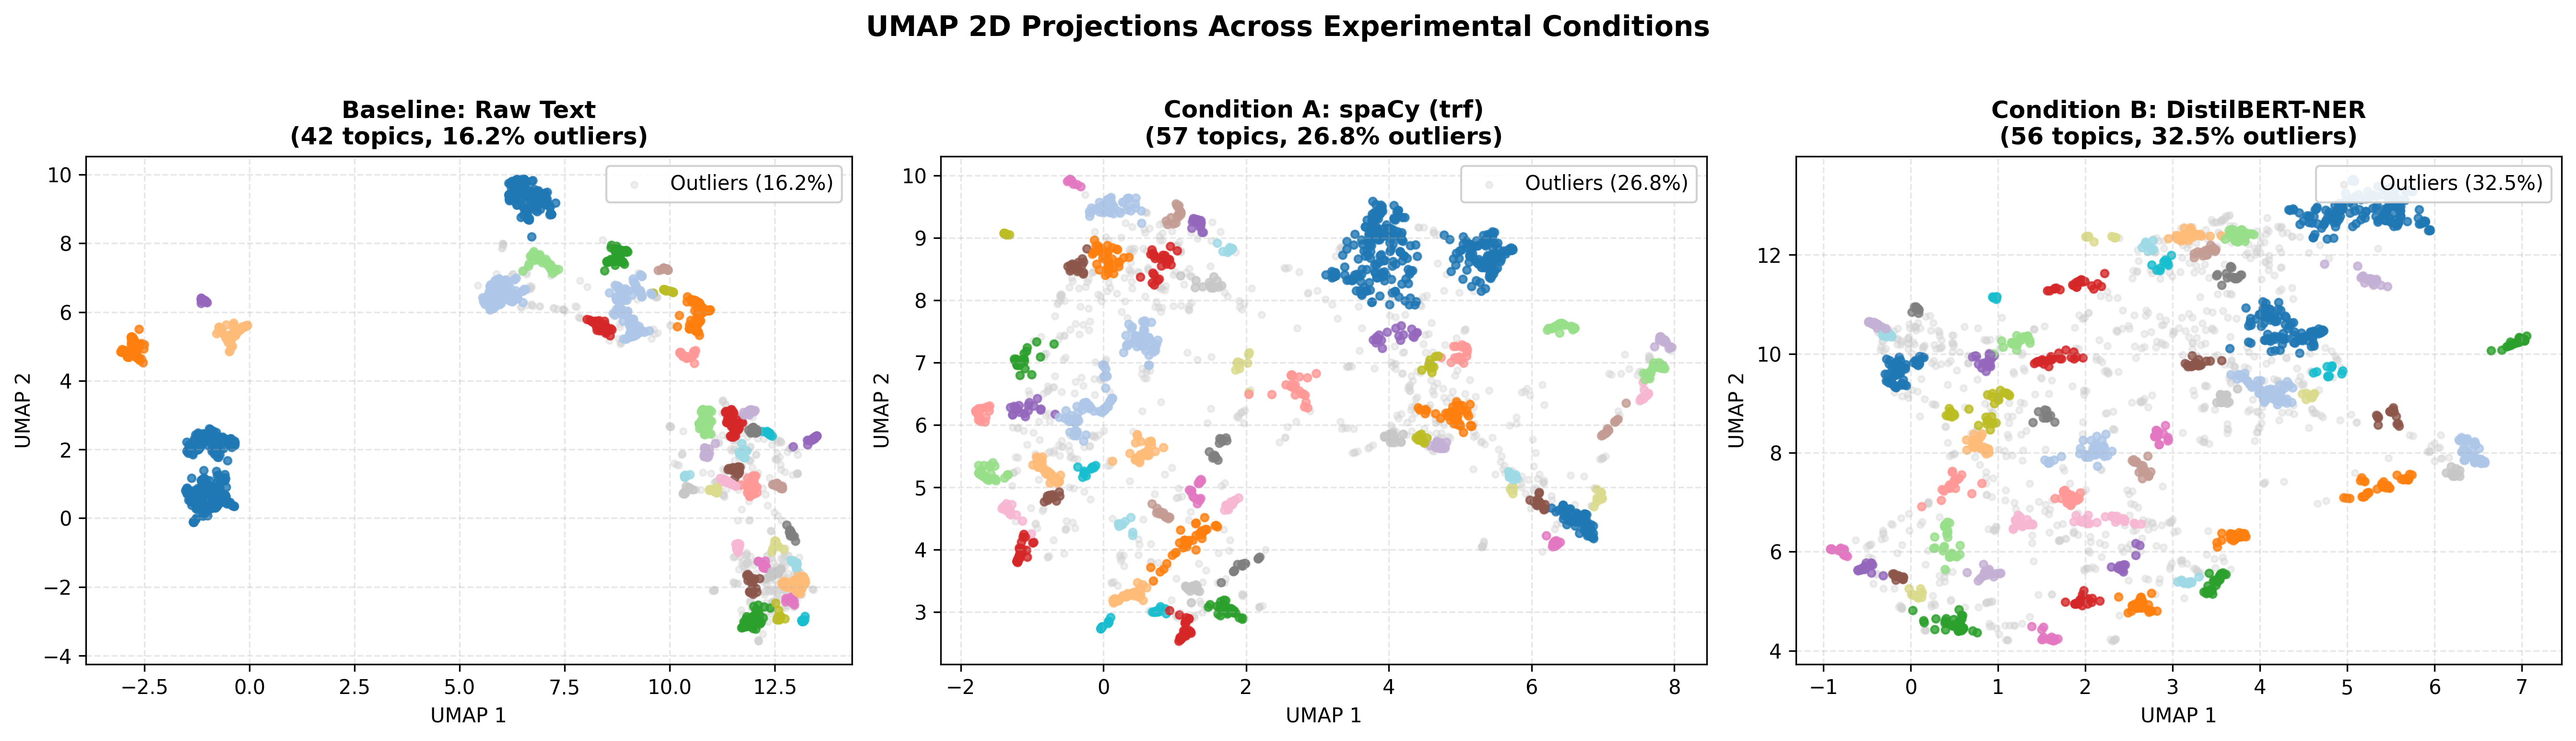

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

runs = [
    ("Baseline: Raw Text", baseline_umap, baseline_topics),
    ("Condition A: spaCy (trf)", cond_a_umap, cond_a_topics),
    ("Condition B: DistilBERT-NER", cond_b_umap, cond_b_topics),
]

for ax, (title, coords, topics) in zip(axes, runs):
    t = np.array(topics)
    outliers = (t == -1)
    out_pct = (outliers.sum() / len(t)) * 100
    n_topics = len(set(t)) - (1 if -1 in t else 0)

    ax.scatter(coords[outliers, 0], coords[outliers, 1], c="#d3d3d3", s=10, alpha=0.35, label=f"Outliers ({out_pct:.1f}%)")
    ax.scatter(coords[~outliers, 0], coords[~outliers, 1], c=t[~outliers], cmap="tab20", s=14, alpha=0.8)
    ax.set_title(f"{title}\n({n_topics} topics, {out_pct:.1f}% outliers)", fontsize=12, fontweight="bold")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend(loc="upper right", framealpha=0.9)

fig.suptitle("UMAP 2D Projections Across Experimental Conditions", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/figure1_umap_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Visualizations: Metrics Comparison

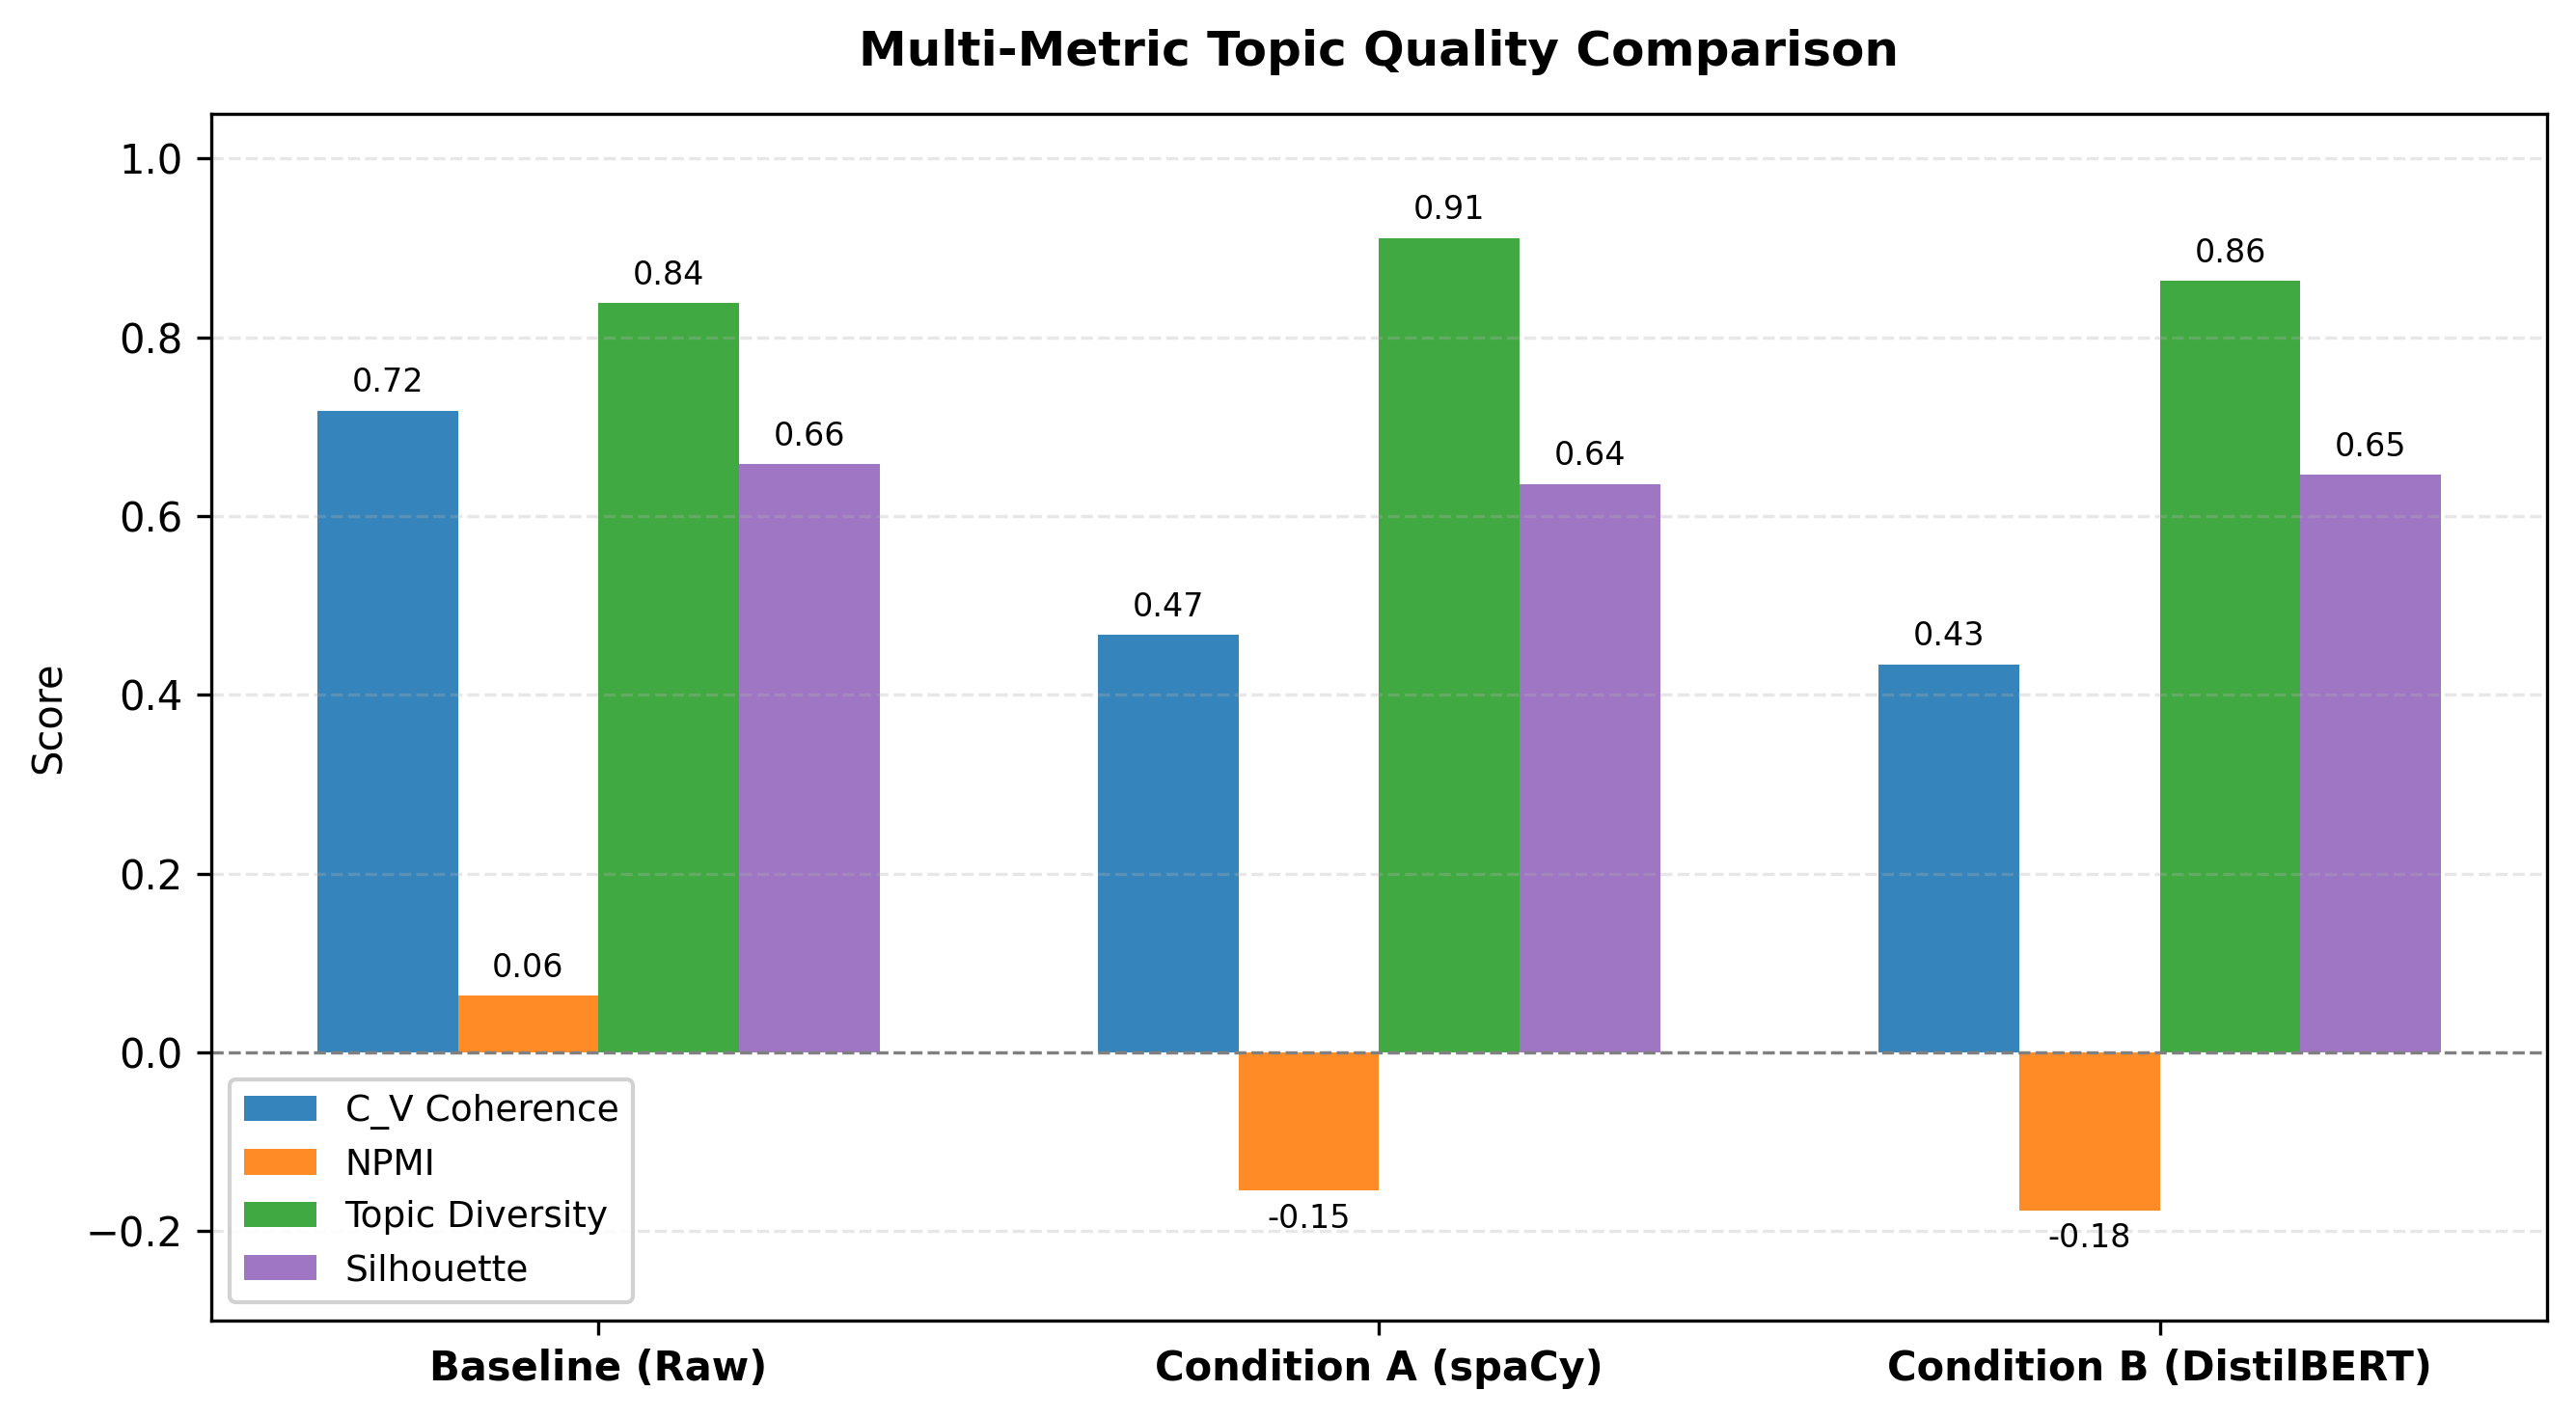

In [8]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

metrics = ["C_V Coherence", "NPMI", "Topic Diversity", "Silhouette"]
labels = ["Baseline (Raw)", "Condition A (spaCy)", "Condition B (DistilBERT)"]
x = np.arange(len(labels))
width = 0.18
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = df_summary[metric].values
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=metric, color=color, alpha=0.9)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight="bold")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylim(-0.3, 1.05)
ax.set_ylabel("Score")
ax.set_title("Multi-Metric Topic Quality Comparison", fontweight="bold", pad=12)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(framealpha=0.9, fontsize=9)

fig.tight_layout()
fig.savefig("figures/figure2_metrics_barchart.png", dpi=300)
plt.show()

## Threshold Sensitivity Analysis
Varying the entity confidence threshold $\tau \in [0.30, 0.95]$ with DistilBERT-NER.

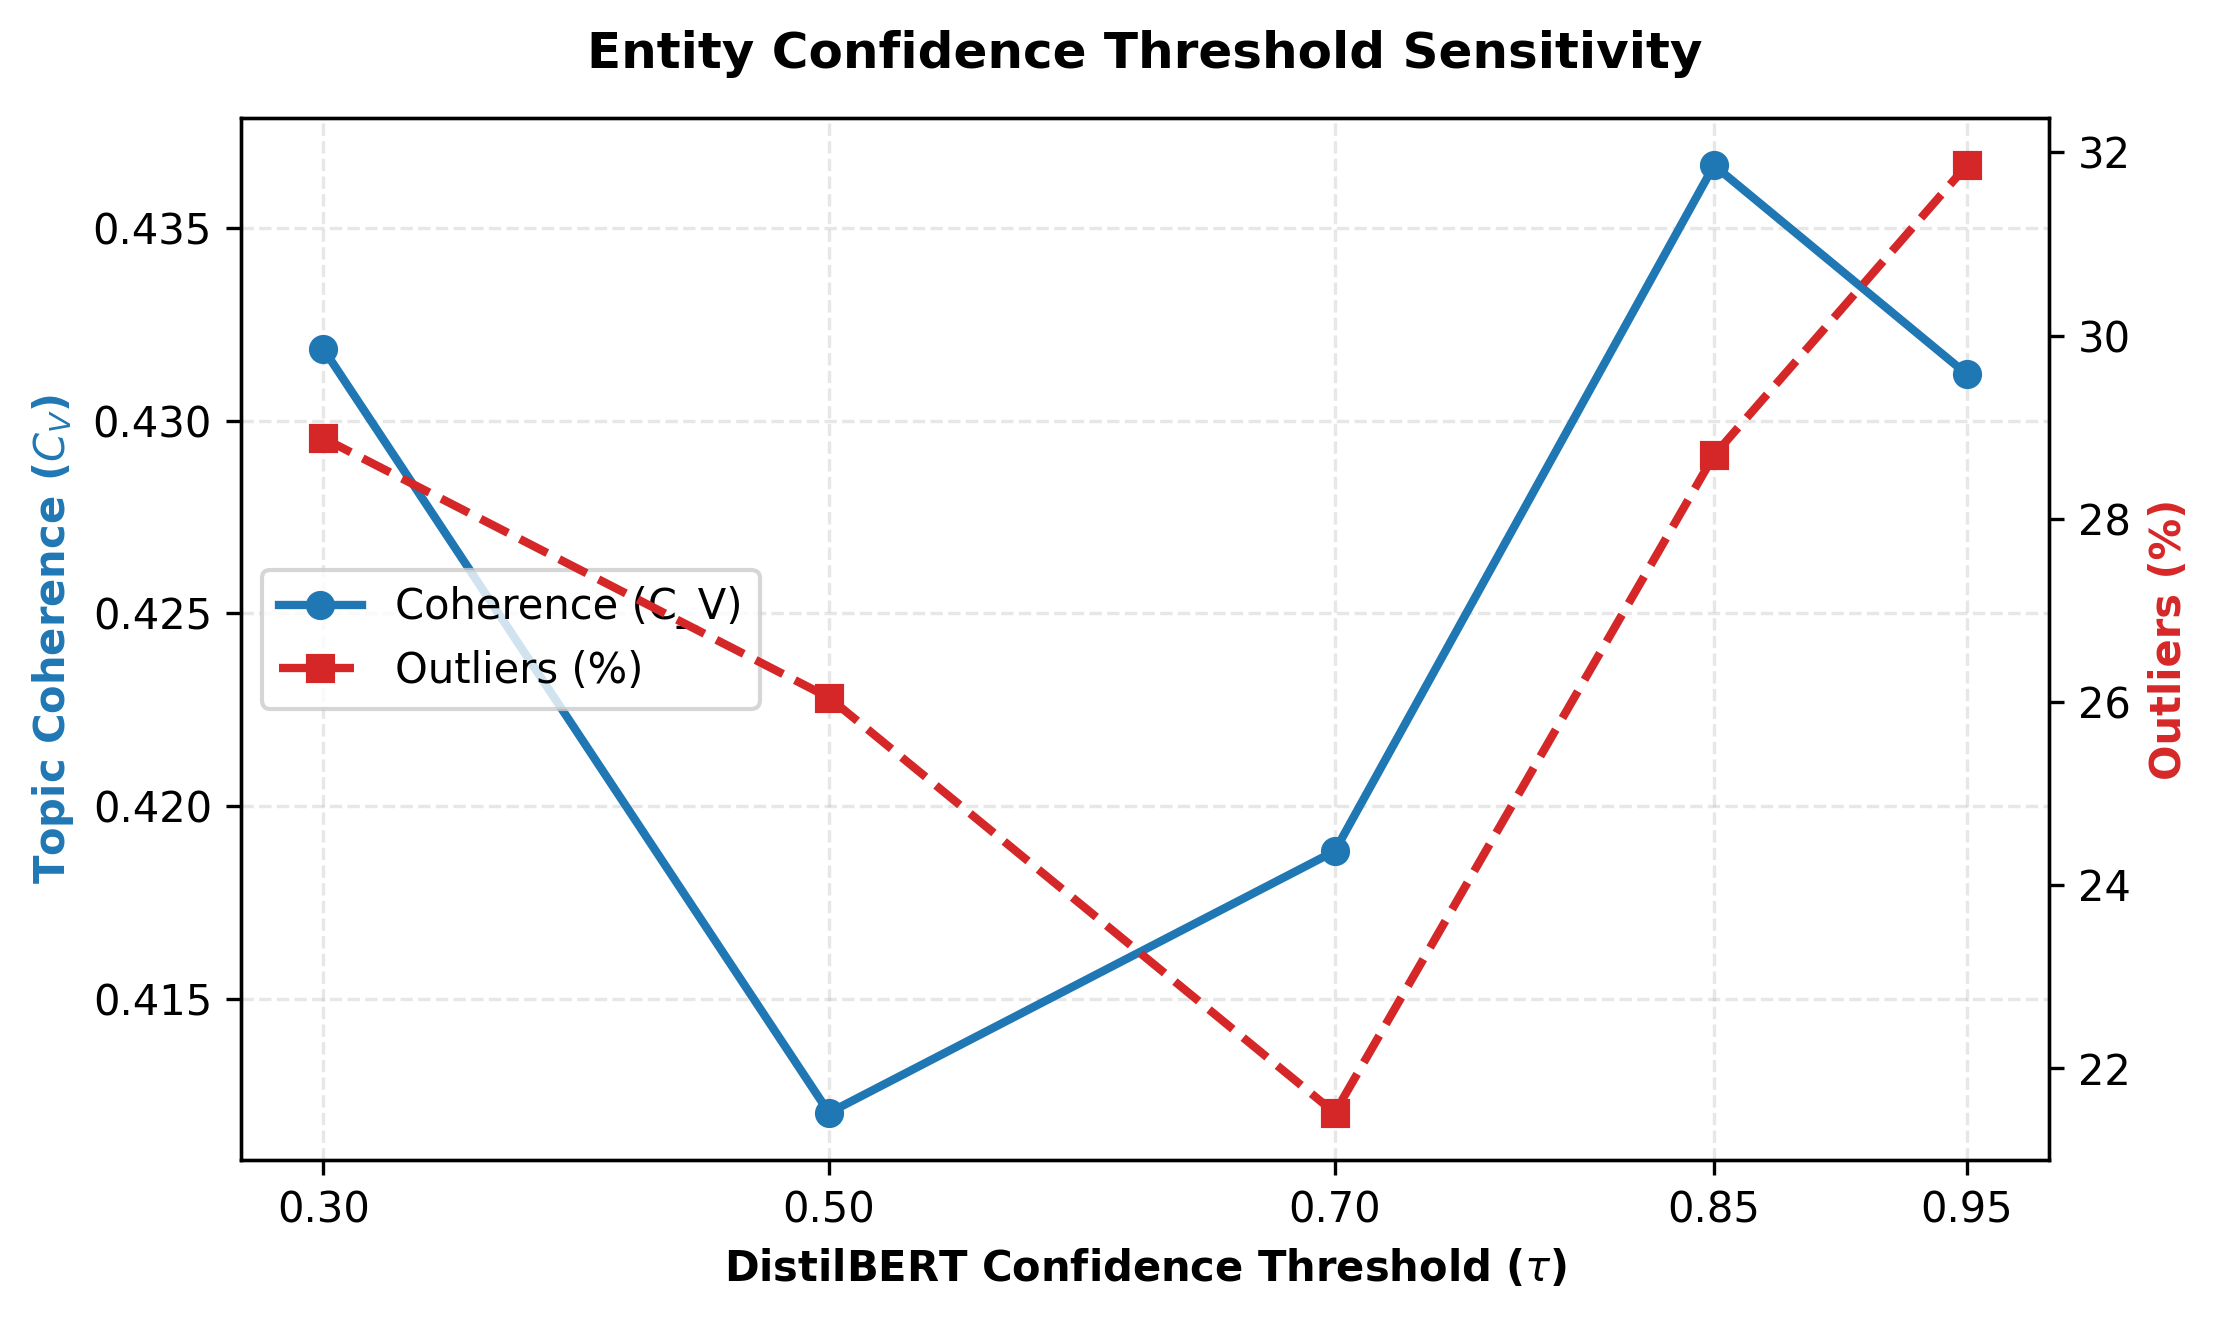

In [9]:
df_sweep = pd.read_csv("results/clean_threshold_sweep_results.csv")

fig, ax1 = plt.subplots(figsize=(7.5, 4.5), dpi=300)
ax2 = ax1.twinx()

l1 = ax1.plot(df_sweep["Threshold"], df_sweep["C_V_Coherence"], "o-", color="#1f77b4", lw=2, label="Coherence (C_V)")
l2 = ax2.plot(df_sweep["Threshold"], df_sweep["Outlier_Pct"], "s--", color="#d62728", lw=2, label="Outliers (%)")

ax1.set_xlabel("DistilBERT Confidence Threshold ($\\tau$)", fontweight="bold")
ax1.set_ylabel("Topic Coherence ($C_V$)", color="#1f77b4", fontweight="bold")
ax2.set_ylabel("Outliers (%)", color="#d62728", fontweight="bold")
ax1.set_xticks(df_sweep["Threshold"])
ax1.grid(True, linestyle="--", alpha=0.3)

lines = l1 + l2
ax1.legend(lines, [l.get_label() for l in lines], loc="center left")
plt.title("Entity Confidence Threshold Sensitivity", fontweight="bold", pad=12)
fig.tight_layout()
fig.savefig("figures/figure3_error_propagation.png", dpi=300)
plt.show()

## Qualitative Cluster Alignment Across Domains

In [10]:
def match_topic(model, keywords):
    best_t, max_hits = -1, 0
    for t in model.get_topics():
        if t == -1:
            continue
        words = [w for w, _ in model.get_topic(t)[:15]]
        hits = sum(1 for kw in keywords if kw.lower() in words)
        if hits > max_hits:
            max_hits, best_t = hits, t
    if best_t != -1:
        top = [w for w, _ in model.get_topic(best_t)[:8]]
        count = (np.array(model.topics_) == best_t).sum()
        return f"{', '.join(top)} (n={count})"
    return "—"

domains = [
    ("UK Politics", ["labour", "blair", "brown", "election", "party", "minister"]),
    ("Football", ["chelsea", "arsenal", "united", "league", "liverpool", "ferguson"]),
    ("Tennis", ["roddick", "federer", "nadal", "hewitt", "open", "tennis"]),
    ("Cinema & Oscars", ["film", "actor", "oscars", "awards", "hollywood", "actress"]),
    ("Stock Exchanges", ["shares", "deutsche", "boerse", "firm", "market", "lse"]),
]

df_table1 = pd.DataFrame([
    {
        "Domain": domain,
        "Baseline (Raw)": match_topic(baseline_model, kws),
        "Condition A (spaCy)": match_topic(cond_a_model, kws),
        "Condition B (DistilBERT)": match_topic(cond_b_model, kws),
    }
    for domain, kws in domains
])

df_table1.to_csv("results/table1_qualitative_comparison.csv", index=False)
df_table1

,Domain,Baseline (Raw),Condition A (spaCy),Condition B (DistilBERT)
0,UK Politics,"blair, labour, mr, election, brown, minister, ...","brown, blair, labour, milburn, peston, gordon,...","brown, labour, blair, gordon, mr, tony, party,..."
1,Football,"club, chelsea, united, arsenal, liverpool, lea...","chelsea, arsenal, mourinho, wenger, ferguson, ...","chelsea, liverpool, arsenal, united, real, man..."
2,Tennis,"roddick, open, seed, australian, match, set, n...","federer, hewitt, safin, lleyton, roger, dent, ...","hewitt, davenport, mirza, fed, williams, seren..."
3,Cinema & Oscars,"film, best, actor, films, director, awards, os...","hollywood, foxx, scorsese, swank, drake, eastw...","drake, vera, ray, eastwood, leigh, foxx, holly..."
4,Stock Exchanges,"lse, boerse, deutsche, euronext, bid, exchange...","eu, lse, boerse, deutsche, euronext, european,...","deutsche, boerse, euro, frankfurt, london, sto..."


## 10. Key References & Resources

1. **BERTopic:** Grootendorst, M. (2022). *BERTopic: Neural topic modeling with a class-based TF-IDF procedure.* [arXiv:2203.05794](https://arxiv.org/abs/2203.05794)
2. **LDA Baseline:** Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). *Latent Dirichlet Allocation.* Journal of Machine Learning Research, 3. [JMLR](https://www.jmlr.org/papers/v3/blei03a.html)
3. **$C_V$ Topic Coherence:** Röder, M., Both, A., & Hinneburg, A. (2015). *Exploring the space of topic coherence measures.* Proceedings of WSDM. [ACM DL](https://dl.acm.org/doi/10.1145/2684822.2685324)
4. **NPMI Coherence:** Bouma, G. (2009). *Normalized (pointwise) mutual information in collocation extraction.* Proceedings of the Biennial GSCL Conference. [GSCL](https://aclanthology.org/)
5. **CoNLL-2003 Shared Task:** Tjong Kim Sang, E. F., & De Meulder, F. (2003). *Introduction to the CoNLL-2003 shared task: Language-independent named entity recognition.* Proceedings of CoNLL. [ACL Anthology](https://aclanthology.org/W03-0419/)
6. **BBC News Benchmark:** Zhang, X., Zhao, J., & LeCun, Y. (2015). *Character-level convolutional networks for text classification.* Advances in Neural Information Processing Systems (NeurIPS), 28. [arXiv:1509.01626](https://arxiv.org/abs/1509.01626)
7. **spaCy Transformer NER:** Honnibal, M., Montani, I., Van Landeghem, S., & Boyd, A. (2020). *spaCy: Industrial-strength Natural Language Processing in Python.* Model: `en_core_web_trf`. [spaCy Docs](https://spacy.io/models/en#en_core_web_trf)
8. **DistilBERT:** Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter.* [arXiv:1910.01108](https://arxiv.org/abs/1910.01108)
9. **Sentence-BERT:** Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence embeddings using Siamese BERT-networks.* Proceedings of EMNLP. [arXiv:1908.10084](https://arxiv.org/abs/1908.10084)
10. **UMAP:** McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction.* [arXiv:1802.03426](https://arxiv.org/abs/1802.03426)
11. **HDBSCAN:** Campello, R. J., Moulavi, D., & Sander, J. (2013). *Density-based clustering based on hierarchical density estimates.* PAKDD. [Springer](https://link.springer.com/chapter/10.1007/978-3-642-37456-2_14)